# Phase 1 — Build a Simple World

## Step 1.1 — Create X values manually

**Goal:** Create a list of evenly spaced `x` values starting at 0.

We will:
1. Start with `x = 0`
2. Use a `for` loop to generate 10 values
3. Store them in a list named `x_values`

**Concepts practiced:**
- Lists
- Loops
- Data representation


In [8]:
import sys
print(sys.executable)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All imports OK ✅")

c:\Users\evertj\git\handson-ml3\ch04\.venv\Scripts\python.exe
All imports OK ✅


In [9]:
# 1. Define the parameters of our sequence
start_value = 0
increment_step = 1
number_of_points = 10

# 2. Initialize an empty list to store the results
x_values = []

# 3. Use a loop to calculate and collect the values
for index in range(number_of_points):
    # Calculate the value for this specific step
    current_value = start_value + (index * increment_step)
    
    # Add the result to our list
    x_values.append(current_value)

print(x_values)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### What just happened?

- `x_values = []` creates an empty list. We’ll fill it one value at a time.
- `x = 0` sets our starting point.
- `step = 1` means each new value will be 1 bigger than the last.

The loop:

- `for _ in range(10)` runs **10 times**
- `x_values.append(x)` pushes the current value of `x` into the list
- `x += step` updates `x` for the next loop iteration

So we get:  
`[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`


In [10]:
import numpy as np
import matplotlib.pyplot as plt

print("Imports OK ✅")


Imports OK ✅


## Step 1.2 — Define a Perfect Linear Relationship

**Goal:** Use our `x_values` to generate matching `y` values.

We will create two versions:

1. **Simple case:**  
   \[
   y = x
   \]

2. **General linear model:**  
   \[
   y = m x + b
   \]

Where:
- `m` is the **slope** (how steep the line is)
- `b` is the **intercept** (where the line hits the y-axis)

**Concepts practiced:**
- Model parameters (slope and intercept)
- Deterministic mapping (same input always gives same output)
- “True generating function” (the hidden rule that created the data)


In [11]:
# Step 1.2 — Define a perfect linear relationship

# 1) Simple case: y = x
y_simple = []
for x in x_values:
    m = 1
    b = 0
    y_simple.append(m * x + b)

# 2) General case: y = m*x + b
m = 2          # slope
b = 3          # intercept

y_linear = []
for x in x_values:
    y_linear.append(m * x + b)

# Let's peek at what we made
print("x_values: ", x_values)
print("y_simple:", y_simple)
print("y_linear:", y_linear)

x_values:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
y_simple: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
y_linear: [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]


### What does “perfect linear relationship” mean?

In this step, we created **two different “world rules”** that generate Y from X.

#### 1) Simple case: `y = x`
This is the simplest possible line.
- If `x = 0`, then `y = 0`
- If `x = 5`, then `y = 5`

So Y always matches X exactly.

#### 2) General case: `y = m*x + b`
This is the classic straight-line equation.

- `m` (slope) controls how fast y changes as x increases.
  - If `m = 2`, then every time x increases by 1, y increases by 2.
- `b` (intercept) shifts the whole line up or down.
  - If `b = 3`, then when x is 0, y starts at 3.

So for `m = 2` and `b = 3`, we get:
- x = 0 → y = 3
- x = 1 → y = 5
- x = 2 → y = 7
…and so on.

### “True generating function”
When we say “true generating function,” we mean:

> The real hidden rule that created the data.

Right now, **we are the gods of this tiny universe**, so we know the truth:
- the “true” slope is `m = 2`
- the “true” intercept is `b = 3`

Later, we’ll pretend we *don’t know* them and use gradient descent to recover them.

## Step 1.3 — Print a Table of X and Y values

**Goal:** Display our dataset in a clear table so we can inspect it.

We will show three columns:
- `x`
- `y_simple` (where `y = x`)
- `y_linear` (where `y = m*x + b`)

We’ll do it two ways:
1. Plain Python printing (great for learning)
2. A Pandas DataFrame (great for analysis later)

In [12]:
# Step 1.3 — Plain Python table printing

print(f"{'index':>5} | {'x':>5} | {'y_simple':>9} | {'y_linear':>8}")
print("-" * 40)

for i in range(len(x_values)):
    x = x_values[i]
    ys = y_simple[i]
    yl = y_linear[i]
    print(f"{i:>5} | {x:>5} | {ys:>9} | {yl:>8}")

index |     x |  y_simple | y_linear
----------------------------------------
    0 |     0 |         0 |        3
    1 |     1 |         1 |        5
    2 |     2 |         2 |        7
    3 |     3 |         3 |        9
    4 |     4 |         4 |       11
    5 |     5 |         5 |       13
    6 |     6 |         6 |       15
    7 |     7 |         7 |       17
    8 |     8 |         8 |       19
    9 |     9 |         9 |       21


### What just happened (plain Python table)?

- We printed a header row with aligned columns using f-strings like `{'x':>5}`.
  - `>5` means “right-align inside a width of 5 characters.”
- Then we printed a separator line.
- We looped over the indices of our lists and printed one row per data point.

Why we did it this way:
- Our data lives in *parallel lists* (`x_values`, `y_simple`, `y_linear`)
- Using the same index across lists keeps each row matched correctly
- This is the simplest “dataset” representation: aligned lists

In [13]:
import pandas as pd

df = pd.DataFrame({
    "x": x_values,
    "y_simple": y_simple,
    "y_linear": y_linear,
})

df

,x,y_simple,y_linear
0,0,0,3
1,1,1,5
2,2,2,7
3,3,3,9
4,4,4,11
5,5,5,13
6,6,6,15
7,7,7,17
8,8,8,19
9,9,9,21


### Why move to a DataFrame?

Right now, our data exists in three parallel lists:
- x_values
- y_simple
- y_linear

That works.

But it’s fragile.

A DataFrame:
- Keeps columns aligned automatically
- Makes statistical operations trivial
- Makes plotting seamless
- Scales cleanly when we add noise

We are slowly evolving from:
“lists in a notebook”

into:
“structured numerical dataset”

This is the first real step toward machine learning territory.

In [14]:
df.describe()

,x,y_simple,y_linear
count,10.00000,10.00000,10.000000
mean,4.50000,4.50000,12.000000
std,3.02765,3.02765,6.055301
min,0.00000,0.00000,3.000000
25%,2.25000,2.25000,7.500000
50%,4.50000,4.50000,12.000000
75%,6.75000,6.75000,16.500000
max,9.00000,9.00000,21.000000


# Step 1.4 — Visualize the Perfect World (Two Lines)

**Goal:** Plot the two deterministic relationships so we can *see* them.

We will plot:
- The simple relationship: `y = x`
- The general linear relationship: `y = m*x + b`

This helps us build intuition before we add noise.

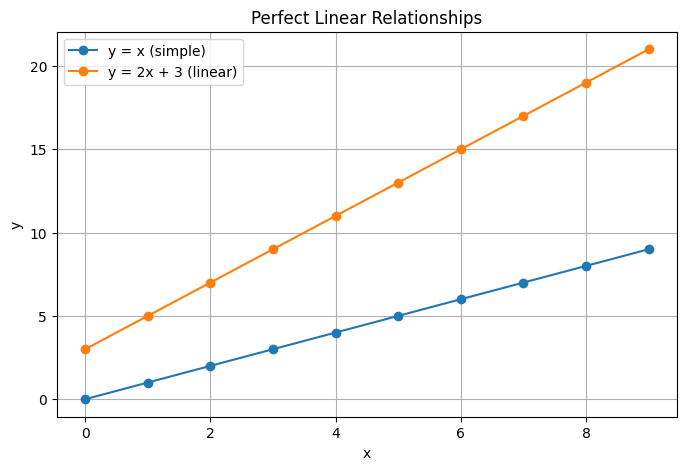

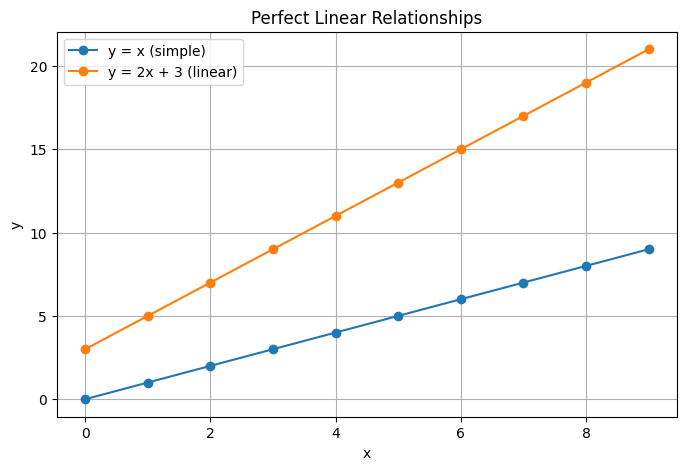

In [17]:
import matplotlib.pyplot as plt

# Plot y = x and y = m*x + b
plt.figure(figsize=(8, 5))
plt.plot(df["x"], df["y_simple"], marker="o", label="y = x (simple)")
plt.plot(df["x"], df["y_linear"], marker="o", label=f"y = {m}x + {b} (linear)")

plt.title("Perfect Linear Relationships")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# Plot y = x and y = m*x + b
plt.figure(figsize=(8, 5))
plt.plot(df["x"], df["y_simple"], marker="o", label="y = x (simple)")
plt.plot(df["x"], df["y_linear"], marker="o", label=f"y = {m}x + {b} (linear)")

plt.title("Perfect Linear Relationships")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

### What should we notice?

- Both are straight lines.
- `y = x` always passes through the origin (0, 0) and rises 1 unit in y for every 1 unit in x.
- `y = m*x + b` shifts and stretches the line:
  - `m` controls steepness (slope)
  - `b` lifts the line up/down (intercept)

Right now, this world is *perfect*:
- same input → same output
- no randomness
- no measurement error

# Phase 2 — Add Reality: Noise

## Step 2.1 — Add Gaussian Noise

**Goal:** Simulate real-world measurements.

We will:
- Create noise sampled from a Gaussian (normal) distribution
- Add it to our linear `y = m*x + b`
- Store the results as `y_noisy`

Parameters:
- `mu` (mean): where the noise is centered (usually 0)
- `sigma` (standard deviation): how “wide” the noise is

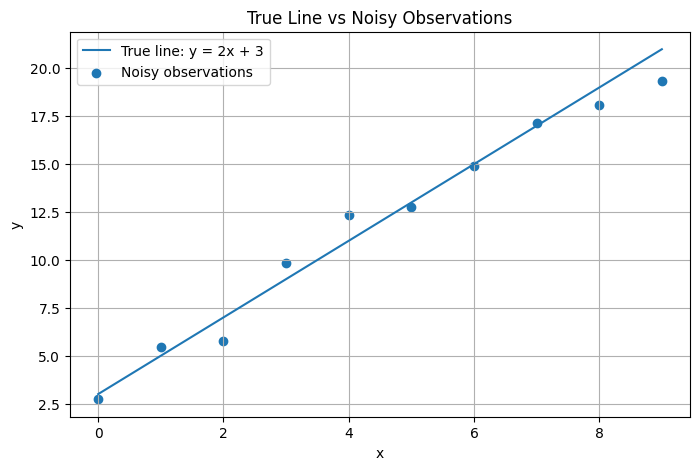

,x,y_simple,y_linear,noise,y_noisy
0,0,0,3,-0.269722,2.730278
1,1,1,5,0.464189,5.464189
2,2,2,7,-1.236346,5.763654
3,3,3,9,0.826571,9.826571
4,4,4,11,1.336544,12.336544
5,5,5,13,-0.220391,12.779609
6,6,6,15,-0.094458,14.905542
7,7,7,17,0.128188,17.128188
8,8,8,19,-0.924007,18.075993
9,9,9,21,-1.674934,19.325066


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Noise settings
mu = 0.0
sigma = 1.0   # try 0.2, 1.0, 3.0 later and watch the universe wobble

# Generate noise and noisy measurements
noise = np.random.normal(loc=mu, scale=sigma, size=len(df))
df["noise"] = noise
df["y_noisy"] = df["y_linear"] + df["noise"]

# Plot: true line + noisy points
plt.figure(figsize=(8, 5))

# True line (smooth)
plt.plot(df["x"], df["y_linear"], label=f"True line: y = {m}x + {b}")

# Noisy observations (scatter)
plt.scatter(df["x"], df["y_noisy"], label="Noisy observations")

plt.title("True Line vs Noisy Observations")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

df